In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display
df = pd.DataFrame()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = '/content/drive/MyDrive/TRAINING SKRIPSI/1. Dataset PDP Sosial Media.xlsx'

df = pd.read_excel(DATA_PATH)

print(df.shape)

df.head()

(2924, 8)


,tanggal_publish,year,creator,source,konten_asli,text,word_count,sentiment
0,2022-01-28 00:00:00,2022,HukumOnline,X,Potret perlindungan data pribadi Indonesia mas...,potret perlindungan data pribadi indonesia mas...,27,negative
1,2022-01-07 00:00:00,2022,sigitwid,X,"Ini serius sekali, apalagi ada data pasien ana...",serius sekali apalagi data pasien anak anak si...,27,negative
2,2022-05-27 00:00:00,2022,tvr_parlemen,X,Perlunya Lembaga Pengawas Perlindungan Data Pr...,perlunya lembaga pengawas perlindungan data pr...,29,neutral
3,2022-01-09 00:00:00,2022,RadioElshinta,X,Koalisi Advokasi Pelindungan Data Pribadi mend...,koalisi advokasi pelindungan data pribadi mend...,34,negative
4,2022-02-01 00:00:00,2022,DS_yantie,X,Substansi di RUU PDP yang sampai saat ini masi...,substansi ruu pdp sampai saat masih digodok me...,28,neutral


In [ ]:
print('Number of data per year:')
display(df['year'].value_counts().sort_index())

Number of data per year:


,count
year,
2020,501
2021,412
2022,291
2023,518
2024,163
2025,1039


In [ ]:
ADDITIONAL_DATA_PATH = '/content/tambahan_2022_2024.xlsx'
df_additional = pd.read_excel(ADDITIONAL_DATA_PATH)

print('Shape of the additional dataset:', df_additional.shape)
display(df_additional.head())

Shape of the additional dataset: (950, 8)


,tanggal_publish,year,creator,source,konten_asli,text,word_count,sentiment
0,2022-09-13 07:11:41+00:00,2022,Aw_Rayy,X,KPU - Komisi Pemilihan Umum Indonesia \n*G I L...,NaN,NaN,NaN
1,2022-09-18 01:09:35+00:00,2022,MediaKomando,X,Mahfud MD Klaim Tak Ada Data Penting yang Boco...,NaN,NaN,NaN
2,2022-09-15 03:09:20+00:00,2022,MediaKomando,X,"Bjorka Diduga Kuat Orang Asli Indonesia, Forum...",NaN,NaN,NaN
3,2022-09-22 00:12:13+00:00,2022,MediaKomando,X,"Tegaskan Tak Ada Data Negara Bocor, Mahfud MD:...",NaN,NaN,NaN
4,2022-09-13 08:14:02+00:00,2022,MediaKomando,X,"Terbaru, Bjorka Bocorkan Data Menko Polhukam M...",NaN,NaN,NaN


Now, let's combine the two DataFrames and remove duplicates based on the 'konten_asli' column. We will keep the entries from the first dataset (`df`) if a duplicate is found.

In [ ]:
# Concatenate the two dataframes. By placing df first, its rows will be kept in case of duplicates.
df_combined = pd.concat([df, df_additional])

# Drop duplicates based on 'konten_asli', keeping the first occurrence
df_deduplicated = df_combined.drop_duplicates(subset=['konten_asli'], keep='first')

print('Shape of the combined and deduplicated dataset:', df_deduplicated.shape)
display(df_deduplicated.head())

Shape of the combined and deduplicated dataset: (3542, 8)


,tanggal_publish,year,creator,source,konten_asli,text,word_count,sentiment
0,2022-01-28 00:00:00,2022,HukumOnline,X,Potret perlindungan data pribadi Indonesia mas...,potret perlindungan data pribadi indonesia mas...,27.0,negative
1,2022-01-07 00:00:00,2022,sigitwid,X,"Ini serius sekali, apalagi ada data pasien ana...",serius sekali apalagi data pasien anak anak si...,27.0,negative
2,2022-05-27 00:00:00,2022,tvr_parlemen,X,Perlunya Lembaga Pengawas Perlindungan Data Pr...,perlunya lembaga pengawas perlindungan data pr...,29.0,neutral
3,2022-01-09 00:00:00,2022,RadioElshinta,X,Koalisi Advokasi Pelindungan Data Pribadi mend...,koalisi advokasi pelindungan data pribadi mend...,34.0,negative
4,2022-02-01 00:00:00,2022,DS_yantie,X,Substansi di RUU PDP yang sampai saat ini masi...,substansi ruu pdp sampai saat masih digodok me...,28.0,neutral


In [ ]:
OUTPUT_PATH = '/content/combined_deduplicated_dataset.xlsx'
df_deduplicated.to_excel(OUTPUT_PATH, index=False)

print(f"Combined and deduplicated data saved to: {OUTPUT_PATH}")

Combined and deduplicated data saved to: /content/combined_deduplicated_dataset.xlsx


In [ ]:
print('Number of records in df_deduplicated per year:')
display(df_deduplicated['year'].value_counts().sort_index())

Number of records in df_deduplicated per year:


,count
year,
2020,501
2021,412
2022,599
2023,518
2024,473
2025,1039


/tmp/ipykernel_2056/484293565.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yearly_counts.index, y=yearly_counts.values, palette='viridis')


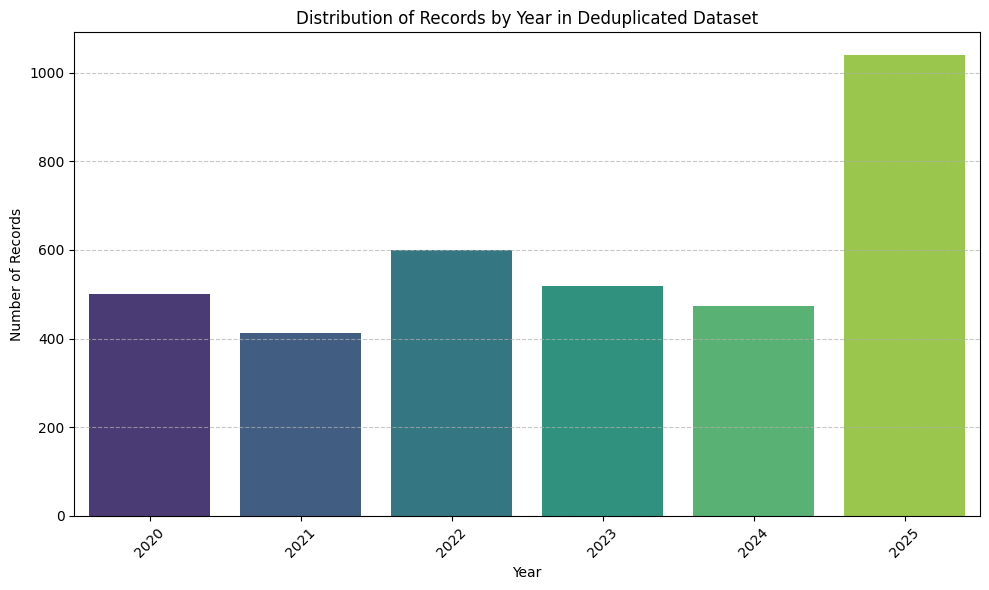

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

yearly_counts = df_deduplicated['year'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=yearly_counts.index, y=yearly_counts.values, palette='viridis')
plt.title('Distribution of Records by Year in Deduplicated Dataset')
plt.xlabel('Year')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
num_unique_konten = df_deduplicated['konten_asli'].nunique()
total_records = len(df_deduplicated)

print(f"Number of unique entries in 'konten_asli': {num_unique_konten}")
print(f"Total records in df_deduplicated: {total_records}")

if num_unique_konten == total_records:
    print("There are no duplicate entries in the 'konten_asli' column.")
else:
    print(f"There are {total_records - num_unique_konten} duplicate entries in the 'konten_asli' column.")

Number of unique entries in 'konten_asli': 3542
Total records in df_deduplicated: 3542
There are no duplicate entries in the 'konten_asli' column.


### Load additional data from `/content/dataset_gabungan_2021.csv`

In [ ]:
ADDITIONAL_CSV_PATH = '/content/dataset_gabungan_2021.csv'
df_csv = pd.read_csv(ADDITIONAL_CSV_PATH)

print('Shape of the new CSV dataset:', df_csv.shape)
display(df_csv.head())

Shape of the new CSV dataset: (468, 15)


,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username
0,1404702728392101889,2021-06-15T07:32:14.000Z,2,@sbmptnfess pengennya sih bisa liat nilai utbk...,1404703277799776258,NaN,sbmptnfess,in,NaN,0,0,0,https://x.com/taufiqutomo/status/1404703277799...,316302486,taufiqutomo
1,1434046227990020099,2021-09-04T06:50:49.000Z,3,Belum lupa dari ingatan sebelumnya kita mengha...,1434046271359049733,NaN,DrKurniasihPKS,in,NaN,0,1,3,https://x.com/DrKurniasihPKS/status/1434046271...,2346865675,DrKurniasihPKS
2,1395205718911819778,2021-05-20T06:10:41.000Z,6,@ndagels Ga kaget kalo data bpjs bocor sih...,1395260671885942787,NaN,ndagels,in,NaN,1,2,1,https://x.com/Monaemon/status/1395260671885942787,39967172,Monaemon
3,1432554700897878021,2021-08-31T10:26:10.000Z,0,"Iya sih data eHAC gak bocor, 'cuma' rawan. Tap...",1432650917371727872,NaN,dicky_p234,in,NaN,0,0,0,https://x.com/dicky_p234/status/14326509173717...,988171922,dicky_p234
4,1410560460856778760,2021-07-02T03:35:35.000Z,0,@DivHumas_Polri Data udah bocor jauh jauh hari...,1410804319771795456,NaN,DivHumas_Polri,in,NaN,0,0,0,https://x.com/dasojie/status/1410804319771795456,60024841,dasojie


### Prepare the new CSV data for concatenation

Based on the request, `full_text` in the CSV should correspond to `konten_asli` in the original DataFrame. I will rename this column and align other columns as needed. If other columns are missing in `df_csv` that are present in `df_deduplicated`, I will add them with `NaN` values to ensure successful concatenation.

In [ ]:
# Rename 'full_text' to 'konten_asli'
df_csv = df_csv.rename(columns={'full_text': 'konten_asli'})

# Get the columns from df_deduplicated
existing_columns = df_deduplicated.columns.tolist()

# Identify columns present in df_csv but not in df_deduplicated
new_csv_columns = df_csv.columns.tolist()
columns_to_drop_from_csv = [col for col in new_csv_columns if col not in existing_columns]
df_csv = df_csv.drop(columns=columns_to_drop_from_csv)

# Identify columns present in df_deduplicated but not in df_csv
columns_to_add_to_csv = [col for col in existing_columns if col not in df_csv.columns]
for col in columns_to_add_to_csv:
    df_csv[col] = np.nan

# Ensure the order of columns matches df_deduplicated
df_csv = df_csv[existing_columns]

print('Shape of the prepared CSV dataset:', df_csv.shape)
display(df_csv.head())

Shape of the prepared CSV dataset: (468, 8)


,tanggal_publish,year,creator,source,konten_asli,text,word_count,sentiment
0,NaN,NaN,NaN,NaN,@sbmptnfess pengennya sih bisa liat nilai utbk...,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,Belum lupa dari ingatan sebelumnya kita mengha...,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,@ndagels Ga kaget kalo data bpjs bocor sih...,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,"Iya sih data eHAC gak bocor, 'cuma' rawan. Tap...",NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,@DivHumas_Polri Data udah bocor jauh jauh hari...,NaN,NaN,NaN


### Combine the existing deduplicated data with the new CSV data and re-deduplicate

In [ ]:
# Concatenate the existing df_deduplicated with the new prepared CSV data
df_combined_new = pd.concat([df_deduplicated, df_csv])

# Drop duplicates based on 'konten_asli', keeping the first occurrence
df_deduplicated_final = df_combined_new.drop_duplicates(subset=['konten_asli'], keep='first')

print('Shape of the final combined and deduplicated dataset:', df_deduplicated_final.shape)
display(df_deduplicated_final.head())

Shape of the final combined and deduplicated dataset: (3773, 8)


,tanggal_publish,year,creator,source,konten_asli,text,word_count,sentiment
0,2022-01-28 00:00:00,2022.0,HukumOnline,X,Potret perlindungan data pribadi Indonesia mas...,potret perlindungan data pribadi indonesia mas...,27.0,negative
1,2022-01-07 00:00:00,2022.0,sigitwid,X,"Ini serius sekali, apalagi ada data pasien ana...",serius sekali apalagi data pasien anak anak si...,27.0,negative
2,2022-05-27 00:00:00,2022.0,tvr_parlemen,X,Perlunya Lembaga Pengawas Perlindungan Data Pr...,perlunya lembaga pengawas perlindungan data pr...,29.0,neutral
3,2022-01-09 00:00:00,2022.0,RadioElshinta,X,Koalisi Advokasi Pelindungan Data Pribadi mend...,koalisi advokasi pelindungan data pribadi mend...,34.0,negative
4,2022-02-01 00:00:00,2022.0,DS_yantie,X,Substansi di RUU PDP yang sampai saat ini masi...,substansi ruu pdp sampai saat masih digodok me...,28.0,neutral


### Verify that there are no duplicate entries in the 'konten_asli' column of the final combined DataFrame

In [ ]:
num_unique_konten_final = df_deduplicated_final['konten_asli'].nunique()
total_records_final = len(df_deduplicated_final)

print(f"Number of unique entries in 'konten_asli' (final): {num_unique_konten_final}")
print(f"Total records in df_deduplicated_final: {total_records_final}")

if num_unique_konten_final == total_records_final:
    print("There are no duplicate entries in the 'konten_asli' column of the final dataset.")
else:
    print(f"There are {total_records_final - num_unique_konten_final} duplicate entries in the 'konten_asli' column of the final dataset.")

Number of unique entries in 'konten_asli' (final): 3773
Total records in df_deduplicated_final: 3773
There are no duplicate entries in the 'konten_asli' column of the final dataset.


### Update `df_deduplicated_final` with specific values from `dataset_gabungan_2021.csv`

In [ ]:
# Reload the raw CSV to access original 'created_at' and 'username' columns
ADDITIONAL_CSV_PATH = '/content/dataset_gabungan_2021.csv'
df_csv_raw = pd.read_csv(ADDITIONAL_CSV_PATH)

# --- START of modification for df_deduplicated_final['tanggal_publish'] ---
# Ensure df_deduplicated_final['tanggal_publish'] is timezone-naive at the start of this cell.
# This handles the mixed tz-aware/tz-naive issue from previous merges.

# Function to convert each element to timezone-naive datetime
def convert_to_naive_datetime(value):
    if pd.isna(value):
        return pd.NaT
    try:
        # Convert to datetime object, coercing errors to NaT
        dt_obj = pd.to_datetime(value, errors='coerce')
        if pd.isna(dt_obj):
            return pd.NaT
        # If it's timezone-aware, localize to None (make it naive)
        if dt_obj.tz is not None:
            return dt_obj.tz_localize(None)
        return dt_obj # Already timezone-naive
    except Exception:
        return pd.NaT

df_deduplicated_final['tanggal_publish'] = df_deduplicated_final['tanggal_publish'].apply(convert_to_naive_datetime)

# Now, df_deduplicated_final['tanggal_publish'] should be a clean series of timezone-naive datetimes or NaT.
# --- END of modification for df_deduplicated_final['tanggal_publish'] ---


# Prepare a temporary DataFrame with the new values
df_csv_processed_for_update = pd.DataFrame()
df_csv_processed_for_update['konten_asli'] = df_csv_raw['full_text']
# Convert 'created_at' to timezone-naive datetime before normalization
df_csv_processed_for_update['tanggal_publish_new'] = pd.to_datetime(df_csv_raw['created_at'], errors='coerce').dt.tz_localize(None).dt.normalize()
df_csv_processed_for_update['year_new'] = 2021
df_csv_processed_for_update['creator_new'] = df_csv_raw['username']
df_csv_processed_for_update['source_new'] = 'X'

# Merge df_deduplicated_final with this processed CSV data
df_deduplicated_final = df_deduplicated_final.merge(
    df_csv_processed_for_update,
    on='konten_asli',
    how='left'
)

# Fill NaN values in the original columns using the new merged columns
# Both df_deduplicated_final['tanggal_publish'] and df_deduplicated_final['tanggal_publish_new']
# should now be timezone-naive (or NaT).
df_deduplicated_final['tanggal_publish'] = df_deduplicated_final['tanggal_publish'].fillna(df_deduplicated_final['tanggal_publish_new'])
df_deduplicated_final['year'] = df_deduplicated_final['year'].fillna(df_deduplicated_final['year_new'])
df_deduplicated_final['creator'] = df_deduplicated_final['creator'].fillna(df_deduplicated_final['creator_new'])
df_deduplicated_final['source'] = df_deduplicated_final['source'].fillna(df_deduplicated_final['source_new'])

# Drop the temporary '_new' columns
df_deduplicated_final = df_deduplicated_final.drop(columns=[
    'tanggal_publish_new', 'year_new', 'creator_new', 'source_new'
])

# Final type conversion for robustness. This line is still useful to ensure the final dtype is datetime64[ns]
# and will not reintroduce the tz-aware/naive issue as the column is now uniform.
df_deduplicated_final['tanggal_publish'] = pd.to_datetime(df_deduplicated_final['tanggal_publish'], errors='coerce')
df_deduplicated_final['year'] = df_deduplicated_final['year'].astype('Int64')

print('Shape of the updated df_deduplicated_final:', df_deduplicated_final.shape)
display(df_deduplicated_final.head())

Shape of the updated df_deduplicated_final: (3773, 8)


,tanggal_publish,year,creator,source,konten_asli,text,word_count,sentiment
0,2022-01-28,2022,HukumOnline,X,Potret perlindungan data pribadi Indonesia mas...,potret perlindungan data pribadi indonesia mas...,27.0,negative
1,2022-01-07,2022,sigitwid,X,"Ini serius sekali, apalagi ada data pasien ana...",serius sekali apalagi data pasien anak anak si...,27.0,negative
2,2022-05-27,2022,tvr_parlemen,X,Perlunya Lembaga Pengawas Perlindungan Data Pr...,perlunya lembaga pengawas perlindungan data pr...,29.0,neutral
3,2022-01-09,2022,RadioElshinta,X,Koalisi Advokasi Pelindungan Data Pribadi mend...,koalisi advokasi pelindungan data pribadi mend...,34.0,negative
4,2022-02-01,2022,DS_yantie,X,Substansi di RUU PDP yang sampai saat ini masi...,substansi ruu pdp sampai saat masih digodok me...,28.0,neutral


### Save the final combined and deduplicated DataFrame to an Excel file

In [ ]:
FINAL_OUTPUT_PATH = '/content/final_combined_deduplicated_dataset.xlsx'
df_deduplicated_final.to_excel(FINAL_OUTPUT_PATH, index=False)

print(f"Final combined and deduplicated data saved to: {FINAL_OUTPUT_PATH}")

Final combined and deduplicated data saved to: /content/final_combined_deduplicated_dataset.xlsx


### Summary of the final combined and deduplicated dataset

In [ ]:
df_deduplicated_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3773 entries, 0 to 3772
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   tanggal_publish  3772 non-null   datetime64[ns]
 1   year             3773 non-null   Int64         
 2   creator          3773 non-null   object        
 3   source           3773 non-null   object        
 4   konten_asli      3773 non-null   object        
 5   text             2924 non-null   object        
 6   word_count       2924 non-null   float64       
 7   sentiment        2924 non-null   object        
dtypes: Int64(1), datetime64[ns](1), float64(1), object(5)
memory usage: 239.6+ KB


### Extracting newly added data without 'text' content

In [ ]:
# Filter df_deduplicated_final to get rows where 'text' is null
df_newly_added_no_text = df_deduplicated_final[df_deduplicated_final['text'].isnull()].copy()

print(f"Shape of the newly added data without 'text': {df_newly_added_no_text.shape}")
display(df_newly_added_no_text.head())

Shape of the newly added data without 'text': (849, 8)


,tanggal_publish,year,creator,source,konten_asli,text,word_count,sentiment
2924,2022-09-13 07:11:41,2022,Aw_Rayy,X,KPU - Komisi Pemilihan Umum Indonesia \n*G I L...,NaN,NaN,NaN
2925,2022-09-18 01:09:35,2022,MediaKomando,X,Mahfud MD Klaim Tak Ada Data Penting yang Boco...,NaN,NaN,NaN
2926,2022-09-15 03:09:20,2022,MediaKomando,X,"Bjorka Diduga Kuat Orang Asli Indonesia, Forum...",NaN,NaN,NaN
2927,2022-09-22 00:12:13,2022,MediaKomando,X,"Tegaskan Tak Ada Data Negara Bocor, Mahfud MD:...",NaN,NaN,NaN
2928,2022-09-13 08:14:02,2022,MediaKomando,X,"Terbaru, Bjorka Bocorkan Data Menko Polhukam M...",NaN,NaN,NaN


### Saving the filtered data to a new Excel file

In [ ]:
OUTPUT_NEWLY_ADDED_PATH = '/content/newly_added_data_no_text.xlsx'
df_newly_added_no_text.to_excel(OUTPUT_NEWLY_ADDED_PATH, index=False)

print(f"Newly added data without 'text' column content saved to: {OUTPUT_NEWLY_ADDED_PATH}")

Newly added data without 'text' column content saved to: /content/newly_added_data_no_text.xlsx


### Preprocessing `konten_asli` column for newly added data

In [ ]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 3.8 MB/s eta 0:00:00


In [ ]:
# Load the newly added data without 'text' content
OUTPUT_NEWLY_ADDED_PATH = '/content/newly_added_data_no_text.xlsx'
df_newly_added_processed = pd.read_excel(OUTPUT_NEWLY_ADDED_PATH)

print(f"Shape of loaded df_newly_added_processed: {df_newly_added_processed.shape}")
display(df_newly_added_processed.head())

Shape of loaded df_newly_added_processed: (849, 8)


,tanggal_publish,year,creator,source,konten_asli,text,word_count,sentiment
0,2022-09-13 07:11:41,2022,Aw_Rayy,X,KPU - Komisi Pemilihan Umum Indonesia \n*G I L...,NaN,NaN,NaN
1,2022-09-18 01:09:35,2022,MediaKomando,X,Mahfud MD Klaim Tak Ada Data Penting yang Boco...,NaN,NaN,NaN
2,2022-09-15 03:09:20,2022,MediaKomando,X,"Bjorka Diduga Kuat Orang Asli Indonesia, Forum...",NaN,NaN,NaN
3,2022-09-22 00:12:13,2022,MediaKomando,X,"Tegaskan Tak Ada Data Negara Bocor, Mahfud MD:...",NaN,NaN,NaN
4,2022-09-13 08:14:02,2022,MediaKomando,X,"Terbaru, Bjorka Bocorkan Data Menko Polhukam M...",NaN,NaN,NaN


In [ ]:
import re
import emoji
import html # Import the html module

def preprocess_text(text):
    if pd.isna(text):
        return ''
    text = str(text)
    # 1. Remove emojis
    text = emoji.replace_emoji(text, '') # More robust emoji removal

    # 2. Convert to lowercase
    text = text.lower()

    # 3. Remove links (URLs)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 4. Remove mentions
    text = re.sub(r'@\w+', '', text)

    # 5. Unescape HTML entities (e.g., '&amp;' to '&')
    text = html.unescape(text)

    # NEW: Remove multiple periods (three or more) to a single space, to address '...' as user specified
    text = re.sub(r'\.{3,}', ' ', text)

    # NEW: Remove multiple question marks (two or more) to a single space, to address '??' as user specified
    text = re.sub(r'\?{2,}', ' ', text)

    # 6. Remove any characters that are not alphanumeric, standard punctuation, or spaces
    # This catches remaining emojis, special symbols like curly quotes, etc.
    text = re.sub(r'[^a-zA-Z0-9.,?!;:\'"()\s-]', '', text)

    # 7. Correct spaced-out words (e.g., 'g i l a' -> 'gila')
    # This regex identifies sequences of single characters separated by spaces within word boundaries.
    text = re.sub(r'\b(\w(?:\s\w)+)\b', lambda m: m.group(1).replace(' ', ''), text)

    # 8. Handle character repetitions for letters, with special 'u' rule
    # First, reduce repetitions of any letter *other than 'u'* (>=2) to 1 instance
    text = re.sub(r'([a-tv-zA-TV-Z])\1+', r'\1', text)
    # Then, reduce 'u' repetitions (3+) to 2 instances
    text = re.sub(r'u{3,}', 'uu', text)

    # Remove extra spaces and leading/trailing spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply preprocessing
df_newly_added_processed['konten_asli_cleaned'] = df_newly_added_processed['konten_asli'].apply(preprocess_text)

# Calculate word count for the cleaned text
df_newly_added_processed['word_count_cleaned'] = df_newly_added_processed['konten_asli_cleaned'].apply(lambda x: len(x.split()))

print("Shape before filtering short texts:", df_newly_added_processed.shape)
# 5. Remove rows that have less than 3 words after cleaning
df_newly_added_processed = df_newly_added_processed[df_newly_added_processed['word_count_cleaned'] >= 3]

print("Shape after filtering short texts:", df_newly_added_processed.shape)
display(df_newly_added_processed[['konten_asli', 'konten_asli_cleaned', 'word_count_cleaned']].head())

Shape before filtering short texts: (667, 10)
Shape after filtering short texts: (667, 10)


,konten_asli,konten_asli_cleaned,word_count_cleaned
0,KPU - Komisi Pemilihan Umum Indonesia \n*G I L...,kpu - komisi pemilihan umum indonesia gila baj...,35
1,Mahfud MD Klaim Tak Ada Data Penting yang Boco...,mahfud md klaim tak ada data penting yang boco...,14
2,"Bjorka Diduga Kuat Orang Asli Indonesia, Forum...","bjorka diduga kuat orang asli indonesia, forum...",19
3,"Tegaskan Tak Ada Data Negara Bocor, Mahfud MD:...","tegaskan tak ada data negara bocor, mahfud md:...",12
4,"Terbaru, Bjorka Bocorkan Data Menko Polhukam M...","terbaru, bjorka bocorkan data menko polhukam m...",18


### Displaying a sample of the processed data

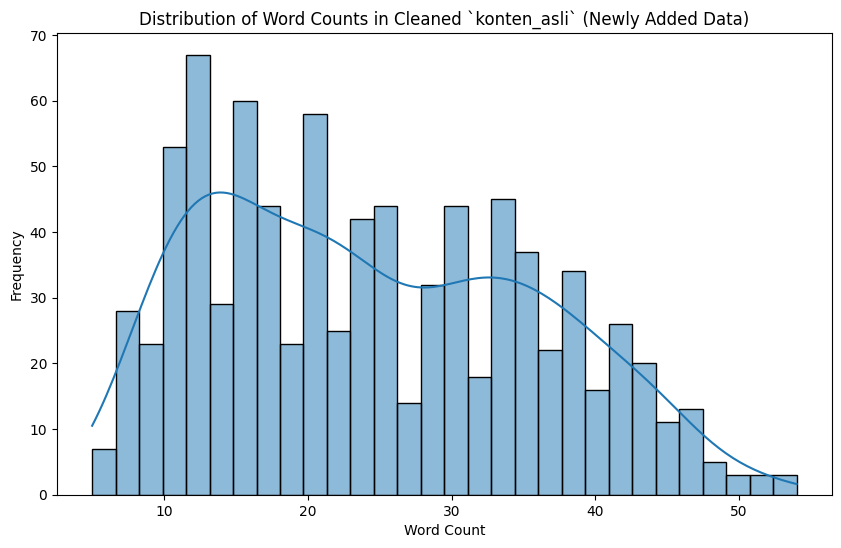

In [ ]:
# Display the distribution of word counts after cleaning
plt.figure(figsize=(10, 6))
sns.histplot(df_newly_added_processed['word_count_cleaned'], bins=30, kde=True)
plt.title('Distribution of Word Counts in Cleaned `konten_asli` (Newly Added Data)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

In [ ]:
display(df_newly_added_processed[['konten_asli', 'konten_asli_cleaned', 'word_count_cleaned']].sample(10))

,konten_asli,konten_asli_cleaned,word_count_cleaned
598,@Dennysiregar7 pantesan data pusat nasional bo...,pantesan data pusat nasional bocor ..eh malh d...,14
602,@gojekbeks Data nasabah beserta data keuangan ...,data nasabah beserta data keuangan nya tetap t...,40
392,Sampai saat ini blm ada bukti bahwa data2 yg s...,sampai sat ini blm ada bukti bahwa data2 yg se...,45
805,2 juta data pribadi nasabah BRI Life diduga bo...,2 juta data pribadi nasabah bri life diduga bo...,20
74,"Ada Nama Warga Cilegon Banten Dicatut Parpol, ...","ada nama warga cilegon banten dicatut parpol, ...",16
834,"Data 279 Juta Penduduk Indonesia Diduga Bocor,...","data 279 juta penduduk indonesia diduga bocor,...",13
841,• Tempo. “Puan Maharani: Data Pribadi Presiden...,tempo. puan maharani: data pribadi presiden jo...,23
264,@CNNIndonesia Yang bocor data rakyat.\n\nTapi ...,yang bocor data rakyat. tapi sepertinya semuan...,21
808,Munarman ini data pribadinya disebar. Rekaman ...,munarman ini data pribadinya disebar. rekaman ...,42
722,Nurul menilai perlu pemerintah menginisiasikan...,nurul menilai perlu pemerintah menginisiasikan...,29


In [ ]:
display(df_newly_added_processed[['konten_asli', 'konten_asli_cleaned']].loc[[281]])

,konten_asli,konten_asli_cleaned
281,@opposite090l92 Tujuannya si Bjorka dan â€œpen...,tujuanya si bjorka dan pendukungnya ini apa? t...


### Saving the preprocessed newly added data

In [ ]:
OUTPUT_PREPROCESSED_NEWLY_ADDED_PATH = '/content/newly_added_data_preprocessed2.xlsx'
df_newly_added_processed.to_excel(OUTPUT_PREPROCESSED_NEWLY_ADDED_PATH, index=False)

print(f"Preprocessed newly added data saved to: {OUTPUT_PREPROCESSED_NEWLY_ADDED_PATH}")

Preprocessed newly added data saved to: /content/newly_added_data_preprocessed2.xlsx


### Examples of Removed Data (less than 3 words after cleaning)

In [ ]:
# First, let's ensure we have the original df_newly_added_no_text before filtering.
# We will use the 'preprocess_text' function defined earlier.

# Create a copy to avoid modifying the original df_newly_added_no_text (if it's still needed elsewhere)
# or reload it if it was modified. For safety, let's reload if it was modified after cell 0dd24c20.
# Assuming df_newly_added_no_text is still in its pre-filtered state from cell 0dd24c20.

df_temp_preprocessed = df_newly_added_no_text.copy()

# Apply preprocessing to 'konten_asli' to get 'konten_asli_cleaned'
df_temp_preprocessed['konten_asli_cleaned'] = df_temp_preprocessed['konten_asli'].apply(preprocess_text)

# Calculate word count for the cleaned text
df_temp_preprocessed['word_count_cleaned'] = df_temp_preprocessed['konten_asli_cleaned'].apply(lambda x: len(x.split()))

# Filter to find rows that would have been removed (word_count_cleaned < 3)
df_removed_examples = df_temp_preprocessed[df_temp_preprocessed['word_count_cleaned'] < 3]

print(f"Number of rows that would have been removed: {len(df_removed_examples)}")

# Display some examples of the removed data
if not df_removed_examples.empty:
    display(df_removed_examples[['konten_asli', 'konten_asli_cleaned', 'word_count_cleaned']].head(10))
else:
    print("No rows were found to be removed with less than 3 words after cleaning in this temporary check.")

Number of rows that would have been removed: 0
No rows were found to be removed with less than 3 words after cleaning in this temporary check.


In [ ]:
# Identify the 'konten_asli' values that were kept in df_newly_added_processed
kept_konten_asli = df_newly_added_processed['konten_asli'].tolist()

# Filter df_newly_added_no_text to find rows whose 'konten_asli' were NOT kept
df_truly_removed = df_newly_added_no_text[~df_newly_added_no_text['konten_asli'].isin(kept_konten_asli)].copy()

print(f"Number of rows that were truly removed: {len(df_truly_removed)}")

# Now, apply the *current* preprocess_text function to these truly removed rows
df_truly_removed['konten_asli_cleaned_current'] = df_truly_removed['konten_asli'].apply(preprocess_text)
df_truly_removed['word_count_cleaned_current'] = df_truly_removed['konten_asli_cleaned_current'].apply(lambda x: len(x.split()))

# Display some examples of these removed rows with their original and currently cleaned versions
if not df_truly_removed.empty:
    display(df_truly_removed[['konten_asli', 'konten_asli_cleaned_current', 'word_count_cleaned_current']].sample(min(10, len(df_truly_removed))))
else:
    print("No rows were found to be removed.")

Number of rows that were truly removed: 182


,konten_asli,konten_asli_cleaned_current,word_count_cleaned_current
3203,@ItsMe_RBH @KPU_ID @bawaslu_RI Keknya ini efek...,keknya ini efek data bocor d kominfo kemaren d...,13
3386,Perlu Adanya Implementasi UU Perlindungan Data...,perlu adanya implementasi uu perlindungan data...,10
3117,UU PDP Bentuk Perhatian Khusus Kepada Perlindu...,uu pdp bentuk perhatian khusus kepada perlindu...,11
3737,Elsam: UU Perlindungan Data Pribadi Harus Sege...,elsam: uu perlindungan data pribadi harus sege...,8
3611,Data nasabah dari asuransi BRI Life diduga boc...,data nasabah dari asuransi bri life diduga boc...,12
3708,Kominfo telah memanggil jajaran direksi BRI Li...,kominfo telah memangil jajaran direksi bri lif...,21
3437,@txtdarigajelas ingfo PERPU/UU yang melarang p...,ingfo perpuu yang melarang penahanan berkas as...,12
3343,Sudah cukup alasan Bagi Presiden utk segera me...,sudah cukup alasan bagi presiden utk segera me...,15
3669,Ini orang yg berbicara elite global 🤣\n\nWakil...,ini orang yg berbicara elite global wakil kepa...,18
3249,Dugaan Pencatutan KTP DKI untuk Dharma Pongrek...,dugan pencatutan ktp dki untuk dharma pongreku...,14
